Clase 10 - Random Forest

In [ ]:
# Librerias 
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
import seaborn as sns
import plotly.express as px
import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path
print ("librerias ok")

d:\Josefina\Proyectos\Datascience\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


librerias ok


In [ ]:
# Ruta del proyecto
ruta_proyecto = Path.cwd().parent
print(ruta_proyecto)
#Ruta donde se encuentra el dataset
ruta_raw = ruta_proyecto  / "housing-price-analysis" / "data"
print(ruta_raw)

#Dataset a utilizar descargado previamente de kaggle 
# https://www.kaggle.com/datasets/marcopale/housing?resource=download
archivo = ruta_raw / "AmesHousing.csv"
housing = pd.read_csv(archivo)

In [8]:
# Creamos dataset de entrenamiento y testeo
x_train, x_test, y_train, y_test = train_test_split (X, y, test_size = 0.2, random_state = 42)

In [22]:
# Se crea y entrena el arbol de decision sin restriccion hasta que encuentre la pureza
# 01. Se setea el modelo con parametros especificados

num_arboles = 100 #n_estimators (ejemplos: 10, 50, 100, 500)
profunidad_max = 3 # max_depth (ejemplos: 3, 5 , 10)


modelo_rf = RandomForestClassifier  (n_estimators = num_arboles,
                                          max_depth = profunidad_max,
                                          random_state = 42)
# 02. Se entrena 
modelo_rf.fit (x_train, y_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [17]:
# Evaluacion del desempeño
# 01. Predicciones del arbol sobre el conjunto de prueba
y_pred = modelo_rf.predict (x_test)


# 02. Precisión
precision = accuracy_score (y_test, y_pred)
print(f"El bosque de {num_arboles} árboles y con  profunidad maxima de {profunidad_max}, logró un Accuracy del {precision * 100:.2f}%")

El bosque de 100 árboles y con  profunidad maxima de 5, logró un Accuracy del 76.22%


In [ ]:
#Hacer pruebas con disitnos hiperparametros
n_arboles_list = [10, 50, 100, 200]
max_depth_list = [3, 5, 10, None]

resultados = []

for n_arboles in n_arboles_list:
    for profundidad_max in max_depth_list:
        
        # Modelo
        rf = RandomForestClassifier(
            n_estimators=n_arboles,
            max_depth=profundidad_max,
            random_state=42
        )
        
        # Entrenamiento
        rf.fit(x_train, y_train)
        
        # Predicción
        y_pred = rf.predict(x_test)
        
        # Métrica
        accuracy = accuracy_score(y_test, y_pred)
        
        # Guardar resultados
        resultados.append({
            "n_estimators": n_arboles,
            "max_depth": profundidad_max,
            "accuracy": accuracy
        })


df_resultados = pd.DataFrame(resultados)

df_resultados.sort_values(by="accuracy", ascending=False)

,n_estimators,max_depth,accuracy
12,200,3.0,0.790210
6,50,10.0,0.783217
13,200,5.0,0.783217
4,50,3.0,0.783217
5,50,5.0,0.776224
8,100,3.0,0.776224
2,10,10.0,0.769231
1,10,5.0,0.769231
14,200,10.0,0.769231
10,100,10.0,0.769231


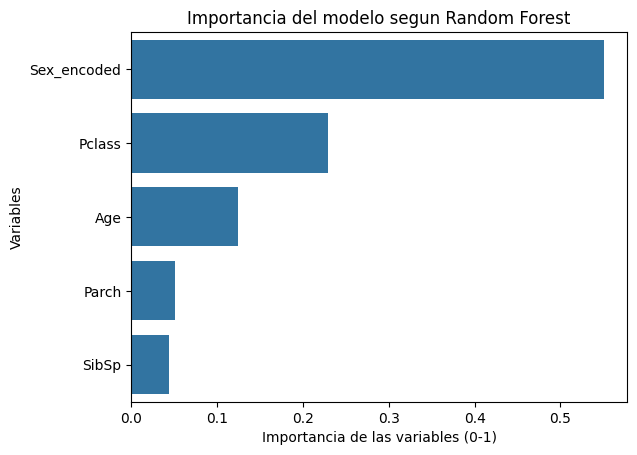

In [23]:
# Prueba de la importancia de cada vairbale

importancia = modelo_rf.feature_importances_

#Asociar cada valor con el nombre de la columna
variable = X.columns
df_importancia = pd.DataFrame({"Variable" : variable, "Importancia":importancia})

#Ordenar de mayor a menor segun importancia
df_importancia = df_importancia.sort_values(by = "Importancia", ascending = False)

#Plot
sns.barplot (x="Importancia", y="Variable", data = df_importancia)
plt.title ("Importancia del modelo segun Random Forest")
plt.xlabel ("Importancia de las variables (0-1)")
plt.ylabel("Variables")
plt.show()

In [24]:
# Evaluacion del desempeño

# 02. Reporte de clasificación
# \ ALT 92
print("Reporte de clasificacion:\n")
print(classification_report(y_test, y_pred))

# 03. Matriz de confusion
print("Matriz de confusión:")
print(confusion_matrix (y_test, y_pred))


Reporte de clasificacion:

              precision    recall  f1-score   support

         0.0       0.80      0.82      0.81        87
         1.0       0.70      0.68      0.69        56

    accuracy                           0.76       143
   macro avg       0.75      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143

Matriz de confusión:
[[71 16]
 [18 38]]
